# Performing PCA on a dataset

## Perfroming PCA to find out which features are the least important in order to improve training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dataHandler import * 


In [5]:
# For the original dataset

# df = pd.read_csv('data/horseData.csv')
# df = clean_data(df)
# df.head(10)

# For the encoded dataset
df = pd.read_csv('data/encodedHorseData.csv', index_col=0)

# Clustering data


## Standardizing the data:

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Droppping names and other non-numeric columns for clustering
target = df['rating']
df = df.drop(columns=['rating', 'sex_C', 'sex_F', 'sex_G', 'sex_R', 'name', 'sire', 'dam', 'bmSire'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

scaled_df.head()


,form,rawErg,erg,age,fee,crop,ems3,damForm,avgSireRating,avgSireErg,avgSireForm,avgDamRating,avgDamErg,avgBmSireRating,avgBmSireErg,avgBmSireForm
1,0.463280,2.318911,1.839478,-0.592763,3.234033,0.696944,1.603220,2.506636,1.510734,1.324676,0.644494,1.018915,1.965782,-1.131305,0.918184,-2.101280
3,2.936648,1.927178,1.928093,0.372220,-0.044909,0.267969,1.495731,-1.187646,1.586370,0.155359,0.714455,1.308547,0.367630,1.302920,-1.154275,1.002932
5,-0.773404,2.878529,2.725631,-0.592763,5.966484,1.125918,1.603220,2.506636,2.078278,2.348096,0.852076,0.823414,2.887995,-0.071623,0.535454,0.036905
7,0.463280,6.236237,5.339781,0.050559,7.332709,1.125918,3.967971,1.583066,1.876689,3.402819,0.269197,2.358464,5.188286,0.881785,1.277436,0.420371
8,-2.010088,4.949116,3.921937,0.372220,3.234033,0.482457,2.678107,-1.187646,2.078278,2.348096,0.852076,0.493957,3.380540,0.554507,-0.148834,0.109295


## Using the elbow method to find the optimum k 

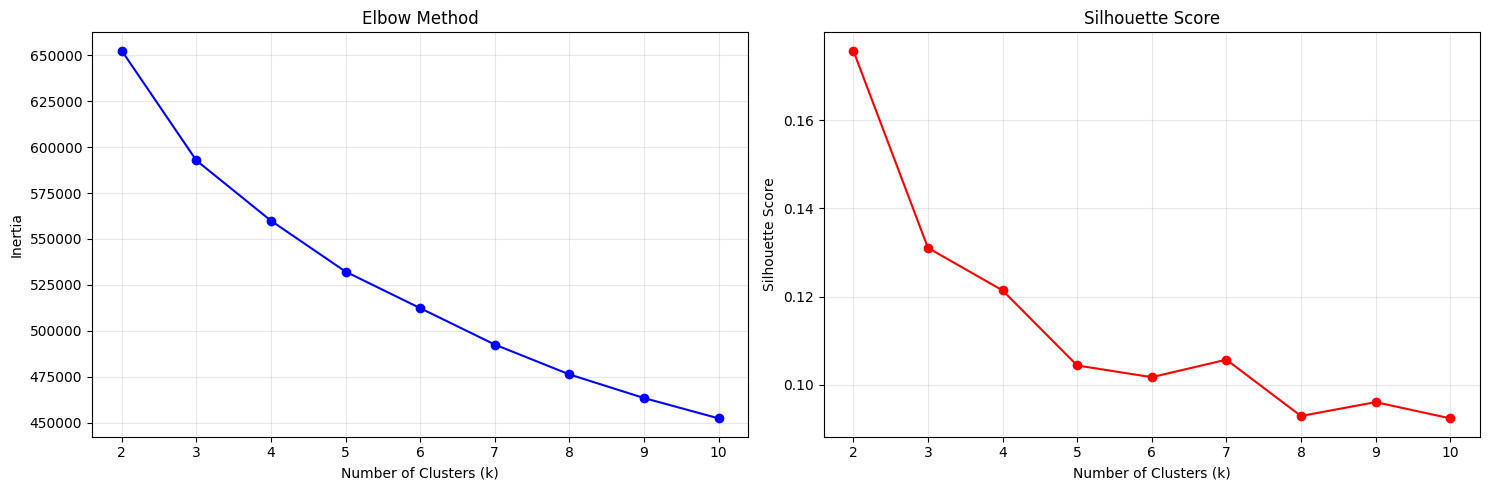

In [7]:
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)
    
    labels = kmeans.labels_
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Performing last k-means and graphing the result via PCA


Clustering with k=2:
Cluster counts:
Cluster
0    31436
1    18538
Name: count, dtype: int64

Cluster Statistics:
             form     rawErg        erg        age           fee      crop  \
Cluster                                                                      
0        1.618940  29.441087  17.507794  10.607552  18445.970543  4.465422   
1        1.636315  54.030532  49.792642   8.546014  54023.447028  7.930090   

              ems3   damForm  avgSireRating  avgSireErg  avgSireForm  \
Cluster                                                                
0        38.025735  1.169201      63.750178   23.786824     1.631279   
1        48.967904  1.483871      68.273568   39.144913     1.615390   

         avgDamRating  avgDamErg  avgBmSireRating  avgBmSireErg  avgBmSireForm  
Cluster                                                                         
0           63.113494  19.156280        64.857615     26.195721       1.623325  
1           69.353232  46.997204        

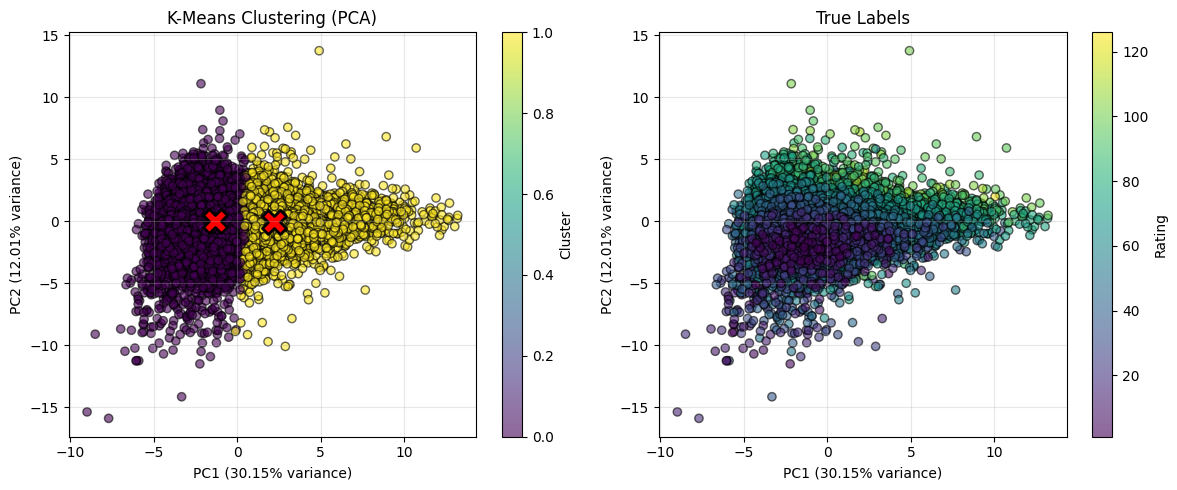

In [8]:
# Step 3: Perform final clustering with optimal k
from sklearn.decomposition import PCA


optimal_k = 2  # Based on the plots

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_data)
centroids = kmeans.cluster_centers_

# Add cluster labels to dataframe
df['Cluster'] = labels

print(f"\nClustering with k={optimal_k}:")
print(f"Cluster counts:\n{df['Cluster'].value_counts().sort_index()}")

# Step 4: Analyze clusters
print("\nCluster Statistics:")
cluster_stats = df.groupby('Cluster').mean()
print(cluster_stats)



# Step 5: Visualize with PCA (reduce to 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

features = df.columns[:-1]  # Exclude 'Cluster' column

print("\nPC1 loadings (how much each feature contributes):")
pc1_loadings = pd.Series(pca.components_[0], index=features).sort_values(ascending=False)
print(pc1_loadings)

print("\nPC2 loadings:")
pc2_loadings = pd.Series(pca.components_[1], index=features).sort_values(ascending=False)
print(pc2_loadings)


plt.figure(figsize=(12, 5))

# Plot 1: Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='black')
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=300, edgecolors='black', linewidths=2)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Plot 2: True labels (if available)
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', alpha=0.6, edgecolors='black')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('True Labels')
plt.colorbar(label='Rating')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()